# AITEX Standalone Kaggle Notebook

This notebook is fully standalone.

It expects only the AITEX dataset from Kaggle `Add Input` and does not depend on the repo being mounted.

Workflow:
1. detect the dataset root under `/kaggle/input`
2. build a grouped train/val/test split
3. train a transfer-learning baseline
4. evaluate the best checkpoint
5. save metrics, figures, and artifacts under `/kaggle/working/aitex-standalone`


In [8]:
from pathlib import Path
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, ResNet18_Weights, efficientnet_b0, resnet18
from torchvision.transforms import InterpolationMode


def find_dataset_root() -> Path:
    for root, dirs, files in os.walk('/kaggle/input'):
        candidate = Path(root)
        if (candidate / 'Defect_images').exists() and (candidate / 'NODefect_images').exists():
            return candidate
    raise FileNotFoundError('Could not find the AITEX dataset under /kaggle/input.')


DATASET_ROOT = find_dataset_root()
WORK_ROOT = Path('/kaggle/working/aitex-standalone')
OUTPUT_DIRS = {
    'manifests': WORK_ROOT / 'data/splits',
    'models': WORK_ROOT / 'outputs/models',
    'metrics': WORK_ROOT / 'outputs/metrics',
    'figures': WORK_ROOT / 'outputs/figures',
    'logs': WORK_ROOT / 'outputs/logs',
}
for path in OUTPUT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

os.environ['TORCH_HOME'] = str(WORK_ROOT / '.cache/torch')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dataset root:', DATASET_ROOT)
print('Working directory:', WORK_ROOT)
print('torch:', torch.__version__)
print('cuda_available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')


Dataset root: /kaggle/input/datasets/nexuswho/aitex-fabric-image-database
Working directory: /kaggle/working/aitex-standalone
torch: 2.10.0+cu128
cuda_available: True
device: Tesla T4


In [9]:
config = {
    'seed': 42,
    'dataset_root': str(DATASET_ROOT),
    'image_size': 224 if device.type == 'cuda' else 160,
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'num_workers': 2 if device.type == 'cuda' else 0,
    'model_name': 'resnet18',
    'pretrained': True,
    'freeze_backbone': False if device.type == 'cuda' else True,
    'batch_size': 16 if device.type == 'cuda' else 4,
    'epochs': 15 if device.type == 'cuda' else 8,
    'learning_rate': 3e-4,
    'weight_decay': 1e-4,
    'scheduler_factor': 0.5,
    'scheduler_patience': 2,
    'early_stopping_patience': 4,
    'decision_threshold': 0.5,
    'amp': device.type == 'cuda',
    'horizontal_flip_prob': 0.5,
    'rotation_degrees': 5,
    'color_jitter': {
        'brightness': 0.05,
        'contrast': 0.05,
        'saturation': 0.05,
        'hue': 0.02,
    },
}

config


{'seed': 42,
 'dataset_root': '/kaggle/input/datasets/nexuswho/aitex-fabric-image-database',
 'image_size': 224,
 'train_ratio': 0.7,
 'val_ratio': 0.15,
 'test_ratio': 0.15,
 'num_workers': 2,
 'model_name': 'resnet18',
 'pretrained': True,
 'freeze_backbone': False,
 'batch_size': 16,
 'epochs': 15,
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'scheduler_factor': 0.5,
 'scheduler_patience': 2,
 'early_stopping_patience': 4,
 'decision_threshold': 0.5,
 'amp': True,
 'horizontal_flip_prob': 0.5,
 'rotation_degrees': 5,
 'color_jitter': {'brightness': 0.05,
  'contrast': 0.05,
  'saturation': 0.05,
  'hue': 0.02}}

In [10]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def collect_mask_map(mask_dir: Path) -> dict[str, list[str]]:
    mask_map = {}
    if not mask_dir.exists():
        return mask_map
    for mask_path in sorted(mask_dir.glob('*.png')):
        stem = mask_path.stem
        base_stem = stem.split('_mask')[0] if '_mask' in stem else stem
        mask_map.setdefault(base_stem, []).append(str(mask_path))
    return mask_map


def scan_aitex_dataset(dataset_root: Path) -> pd.DataFrame:
    defect_dir = dataset_root / 'Defect_images'
    mask_dir = dataset_root / 'Mask_images'
    normal_dir = dataset_root / 'NODefect_images'
    mask_map = collect_mask_map(mask_dir)
    records = []

    for image_path in sorted(defect_dir.glob('*.png')):
        parts = image_path.stem.split('_')
        group_id = f"defect_{parts[1]}_{parts[2]}"
        records.append({
            'image_path': str(image_path),
            'label': 1,
            'label_name': 'defective',
            'group_id': group_id,
            'mask_paths': ';'.join(mask_map.get(image_path.stem, [])),
        })

    for image_path in sorted(normal_dir.rglob('*.png')):
        if not image_path.is_file():
            continue
        records.append({
            'image_path': str(image_path),
            'label': 0,
            'label_name': 'non_defective',
            'group_id': f"normal_{image_path.parent.name}",
            'mask_paths': '',
        })

    manifest = pd.DataFrame.from_records(records)
    return manifest.sort_values('image_path').reset_index(drop=True)


def create_group_split_manifest(manifest: pd.DataFrame, train_ratio: float, val_ratio: float, test_ratio: float, seed: int) -> pd.DataFrame:
    group_table = manifest.groupby('group_id').agg(label=('label', 'first'), sample_count=('image_path', 'size')).reset_index()
    stratify_first = group_table['label'] if group_table['label'].value_counts().min() >= 2 else None
    train_groups, temp_groups = train_test_split(
        group_table,
        test_size=(1.0 - train_ratio),
        stratify=stratify_first,
        random_state=seed,
    )
    val_fraction = val_ratio / (val_ratio + test_ratio)
    stratify_second = temp_groups['label'] if temp_groups['label'].value_counts().min() >= 2 else None
    val_groups, test_groups = train_test_split(
        temp_groups,
        test_size=(1.0 - val_fraction),
        stratify=stratify_second,
        random_state=seed + 1,
    )

    train_df = manifest[manifest['group_id'].isin(train_groups['group_id'])].copy()
    val_df = manifest[manifest['group_id'].isin(val_groups['group_id'])].copy()
    test_df = manifest[manifest['group_id'].isin(test_groups['group_id'])].copy()
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    test_df['split'] = 'test'
    return pd.concat([train_df, val_df, test_df], ignore_index=True)


def summarize_manifest(manifest: pd.DataFrame) -> dict:
    split_counts = manifest.groupby(['split', 'label_name']).size().unstack(fill_value=0)
    split_sizes = manifest['split'].value_counts().to_dict()
    return {
        'num_samples': int(len(manifest)),
        'num_groups': int(manifest['group_id'].nunique()),
        'split_sizes': {key: int(value) for key, value in split_sizes.items()},
        'split_label_counts': {
            split: {label: int(count) for label, count in counts.items()}
            for split, counts in split_counts.to_dict(orient='index').items()
        },
    }


seed_everything(config['seed'])
manifest = scan_aitex_dataset(DATASET_ROOT)
split_manifest = create_group_split_manifest(
    manifest,
    train_ratio=config['train_ratio'],
    val_ratio=config['val_ratio'],
    test_ratio=config['test_ratio'],
    seed=config['seed'],
)
summary = summarize_manifest(split_manifest)

manifest_path = OUTPUT_DIRS['manifests'] / 'manifest.csv'
summary_path = OUTPUT_DIRS['manifests'] / 'split_summary.json'
split_manifest.to_csv(manifest_path, index=False)
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print(summary)
display(split_manifest.head())
display(split_manifest.groupby(['split', 'label_name']).size().unstack(fill_value=0))


{'num_samples': 247, 'num_groups': 33, 'split_sizes': {'train': 180, 'val': 41, 'test': 26}, 'split_label_counts': {'test': {'defective': 6, 'non_defective': 20}, 'train': {'defective': 80, 'non_defective': 100}, 'val': {'defective': 20, 'non_defective': 21}}}


,image_path,label,label_name,group_id,mask_paths,split
0,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,1,defective,defect_002_00,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,train
1,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,1,defective,defect_002_00,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,train
2,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,1,defective,defect_002_00,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,train
3,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,1,defective,defect_002_01,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,train
4,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,1,defective,defect_002_01,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,train


label_name,defective,non_defective
split,,
test,6,20
train,80,100
val,20,21


In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class AITEXDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, split: str, transform=None):
        self.samples = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        row = self.samples.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return {
            'image': image,
            'label': torch.tensor(float(row['label']), dtype=torch.float32),
            'image_path': row['image_path'],
        }


def build_train_transform(config: dict):
    jitter = config['color_jitter']
    return transforms.Compose([
        transforms.Resize((config['image_size'], config['image_size']), interpolation=InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(p=config['horizontal_flip_prob']),
        transforms.RandomRotation(config['rotation_degrees']),
        transforms.ColorJitter(
            brightness=jitter['brightness'],
            contrast=jitter['contrast'],
            saturation=jitter['saturation'],
            hue=jitter['hue'],
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def build_eval_transform(config: dict):
    return transforms.Compose([
        transforms.Resize((config['image_size'], config['image_size']), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def create_model(model_name: str, pretrained: bool = True, freeze_backbone: bool = False) -> nn.Module:
    if model_name == 'resnet18':
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, 1)
    elif model_name == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = efficientnet_b0(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    else:
        raise ValueError(f'Unsupported model name: {model_name}')

    if freeze_backbone:
        for name, parameter in model.named_parameters():
            if 'fc' in name or 'classifier' in name:
                parameter.requires_grad = True
            else:
                parameter.requires_grad = False

    return model


def compute_pos_weight(labels: list[int]):
    positive_count = sum(labels)
    negative_count = len(labels) - positive_count
    if positive_count == 0 or negative_count == 0:
        return None
    return negative_count / positive_count


def build_criterion(labels: list[int]):
    pos_weight = compute_pos_weight(labels)
    if pos_weight is None:
        return nn.BCEWithLogitsLoss()
    return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = [int(prob >= threshold) for prob in y_prob]
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    metrics['roc_auc'] = roc_auc_score(y_true, y_prob) if len(set(y_true)) == 2 else None
    return metrics


def save_confusion_figure(matrix, output_path: Path):
    figure = plt.figure(figsize=(5, 4))
    sns.heatmap(np.array(matrix), annot=True, fmt='d', cmap='Blues', xticklabels=['non_defective', 'defective'], yticklabels=['non_defective', 'defective'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    figure.savefig(output_path, dpi=200)
    plt.close(figure)


def save_history_figure(history, output_path: Path):
    epochs = range(1, len(history['train_loss']) + 1)
    figure, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, history['train_loss'], label='train_loss')
    axes[0].plot(epochs, history['val_loss'], label='val_loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(epochs, history['train_f1'], label='train_f1')
    axes[1].plot(epochs, history['val_f1'], label='val_f1')
    axes[1].set_title('F1')
    axes[1].legend()
    plt.tight_layout()
    figure.savefig(output_path, dpi=200)
    plt.close(figure)


def run_epoch(model, dataloader, criterion, optimizer=None, threshold=0.5):
    is_training = optimizer is not None
    model.train(is_training)
    amp_enabled = config['amp'] and device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    running_loss = 0.0
    y_true, y_prob, image_paths = [], [], []

    for batch in dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

        if is_training:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        probabilities = torch.sigmoid(logits).detach().cpu().tolist()
        y_prob.extend(float(prob) for prob in probabilities)
        y_true.extend(int(value) for value in labels.detach().cpu().tolist())
        image_paths.extend(batch['image_path'])
        running_loss += loss.item() * images.size(0)

    metrics = compute_metrics(y_true, y_prob, threshold=threshold)
    metrics['loss'] = running_loss / len(dataloader.dataset)
    metrics['y_true'] = y_true
    metrics['y_prob'] = y_prob
    metrics['image_paths'] = image_paths
    return metrics


In [12]:
train_dataset = AITEXDataset(split_manifest, split='train', transform=build_train_transform(config))
val_dataset = AITEXDataset(split_manifest, split='val', transform=build_eval_transform(config))

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

model = create_model(
    model_name=config['model_name'],
    pretrained=config['pretrained'],
    freeze_backbone=config['freeze_backbone'],
).to(device)

train_labels = split_manifest[split_manifest['split'] == 'train']['label'].astype(int).tolist()
criterion = build_criterion(train_labels)
optimizer = AdamW(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=config['learning_rate'],
    weight_decay=config['weight_decay'],
)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=config['scheduler_factor'],
    patience=config['scheduler_patience'],
)

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_f1 = float('-inf')
patience_counter = 0
checkpoint_path = OUTPUT_DIRS['models'] / 'best_model.pt'

for epoch in range(1, config['epochs'] + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, threshold=config['decision_threshold'])
    with torch.no_grad():
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, threshold=config['decision_threshold'])

    scheduler.step(val_metrics['f1'])
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])

    print(
        f"Epoch {epoch:02d} | train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_name': config['model_name'],
            'threshold': config['decision_threshold'],
            'config': config,
            'best_val_metrics': {
                'loss': val_metrics['loss'],
                'accuracy': val_metrics['accuracy'],
                'precision': val_metrics['precision'],
                'recall': val_metrics['recall'],
                'f1': val_metrics['f1'],
                'roc_auc': val_metrics['roc_auc'],
                'confusion_matrix': val_metrics['confusion_matrix'],
            },
        }, checkpoint_path)
    else:
        patience_counter += 1
        if patience_counter >= config['early_stopping_patience']:
            print(f'Early stopping at epoch {epoch}')
            break

history_path = OUTPUT_DIRS['models'] / 'training_history.json'
history_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
save_history_figure(history, OUTPUT_DIRS['figures'] / 'training_curves.png')

print('Best validation F1:', best_f1)
print('Checkpoint:', checkpoint_path)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /kaggle/working/aitex-standalone/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s] 


Epoch 01 | train_loss=0.8557 train_f1=0.5763 | val_loss=0.8985 val_f1=0.6557
Epoch 02 | train_loss=0.7261 train_f1=0.6329 | val_loss=1.8246 val_f1=0.4490
Epoch 03 | train_loss=0.6785 train_f1=0.7018 | val_loss=1.9251 val_f1=0.5091
Epoch 04 | train_loss=0.5211 train_f1=0.7237 | val_loss=1.2511 val_f1=0.5652
Epoch 05 | train_loss=0.3941 train_f1=0.8302 | val_loss=1.8535 val_f1=0.5532
Early stopping at epoch 5
Best validation F1: 0.6557377049180327
Checkpoint: /kaggle/working/aitex-standalone/outputs/models/best_model.pt


In [15]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
best_model = create_model(checkpoint['model_name'], pretrained=False, freeze_backbone=False).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

test_dataset = AITEXDataset(split_manifest, split='test', transform=build_eval_transform(config))
test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=(device.type == 'cuda'),
)

with torch.no_grad():
    test_metrics = run_epoch(best_model, test_loader, criterion, optimizer=None, threshold=checkpoint['threshold'])

failure_cases = []
for truth, probability, image_path in zip(test_metrics['y_true'], test_metrics['y_prob'], test_metrics['image_paths']):
    prediction = int(probability >= checkpoint['threshold'])
    if prediction == truth:
        continue
    confidence = probability if prediction == 1 else (1.0 - probability)
    failure_cases.append({
        'image_path': image_path,
        'true_label': 'defective' if truth == 1 else 'non_defective',
        'predicted_label': 'defective' if prediction == 1 else 'non_defective',
        'defective_probability': float(probability),
        'confidence': float(confidence),
    })
failure_cases = sorted(failure_cases, key=lambda item: item['confidence'], reverse=True)[:10]

test_metrics['checkpoint'] = str(checkpoint_path)
test_metrics['best_val_metrics'] = checkpoint.get('best_val_metrics', {})
test_metrics['failure_cases'] = failure_cases

metrics_path = OUTPUT_DIRS['metrics'] / 'test_metrics.json'
metrics_path.write_text(json.dumps(test_metrics, indent=2), encoding='utf-8')
save_confusion_figure(test_metrics['confusion_matrix'], OUTPUT_DIRS['figures'] / 'test_confusion_matrix.png')

summary_view = {
    'accuracy': test_metrics['accuracy'],
    'precision': test_metrics['precision'],
    'recall': test_metrics['recall'],
    'f1': test_metrics['f1'],
    'roc_auc': test_metrics['roc_auc'],
    'confusion_matrix': test_metrics['confusion_matrix'],
}
summary_view


{'accuracy': 0.4230769230769231,
 'precision': 0.2857142857142857,
 'recall': 1.0,
 'f1': 0.4444444444444444,
 'roc_auc': np.float64(1.0),
 'confusion_matrix': [[5, 15], [0, 6]]}

,image_path,true_label,predicted_label,defective_probability,confidence
0,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.601074,0.601074
1,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.600098,0.600098
2,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.597656,0.597656
3,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.591309,0.591309
4,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.585449,0.585449
5,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.581055,0.581055
6,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.578613,0.578613
7,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.576660,0.576660
8,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.565430,0.565430
9,/kaggle/input/datasets/nexuswho/aitex-fabric-i...,non_defective,defective,0.554688,0.554688


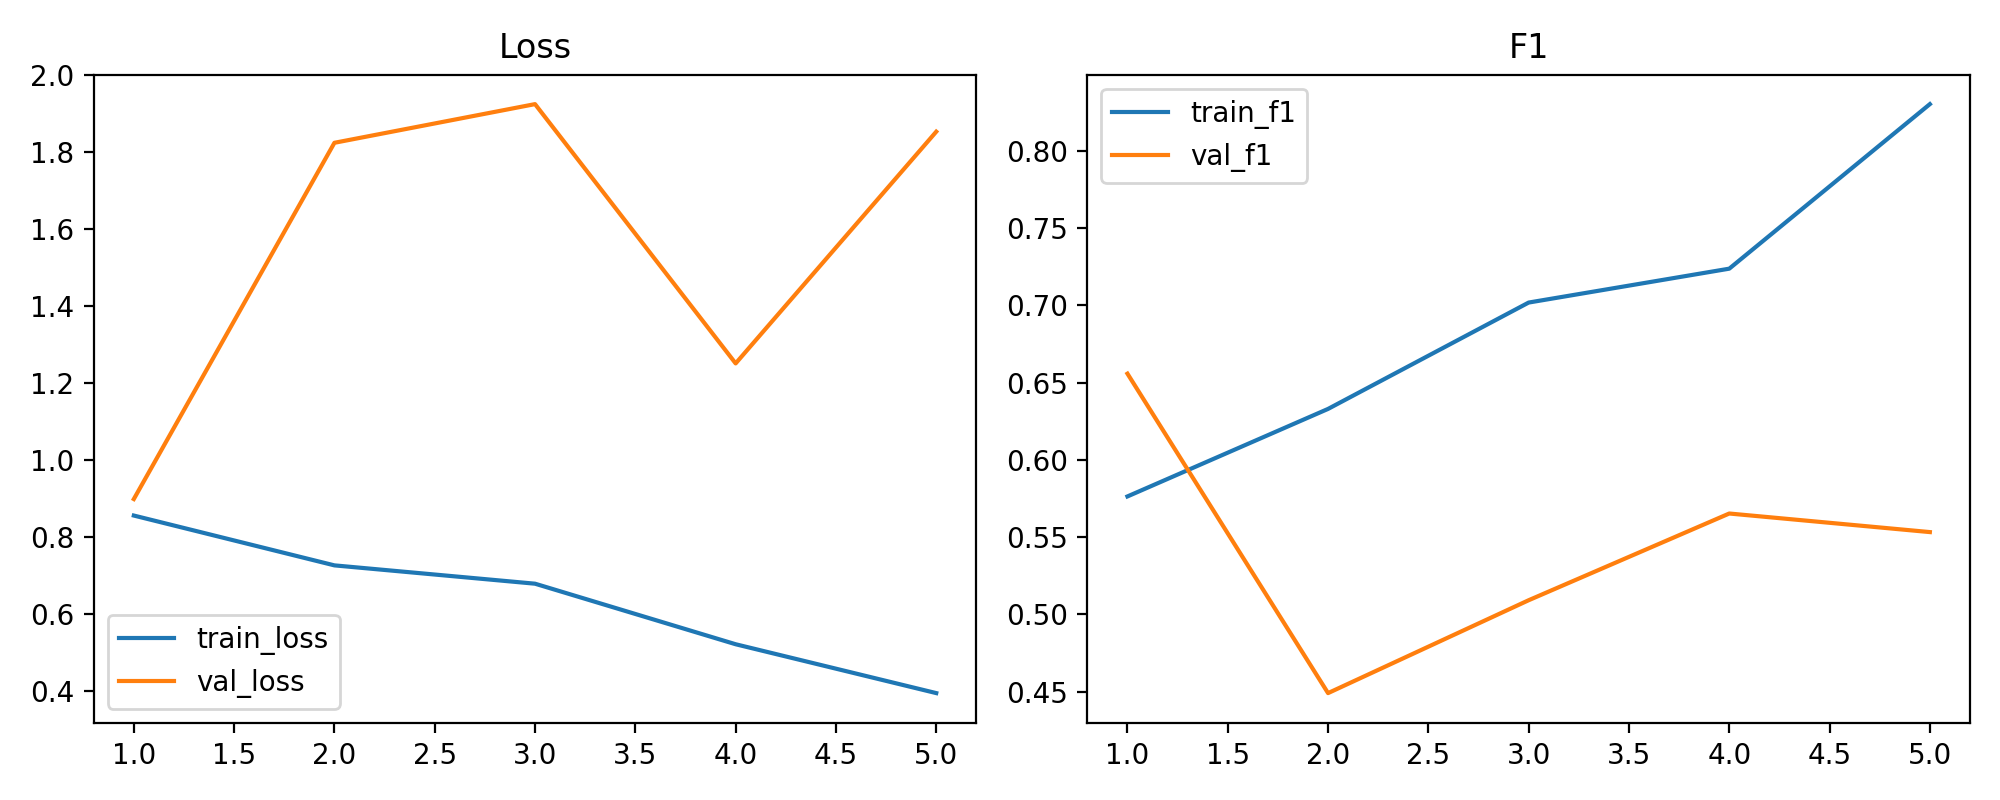

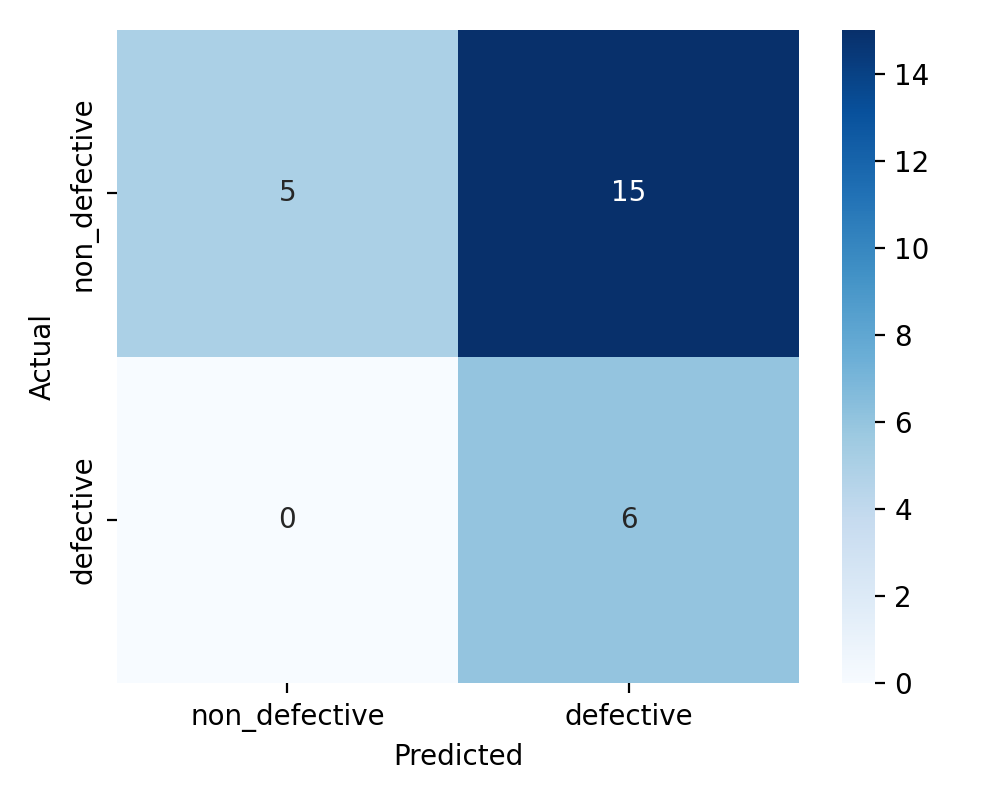

In [16]:
from IPython.display import Image as IPyImage, display

display(pd.DataFrame(test_metrics['failure_cases']))
display(IPyImage(filename=str(OUTPUT_DIRS['figures'] / 'training_curves.png')))
display(IPyImage(filename=str(OUTPUT_DIRS['figures'] / 'test_confusion_matrix.png')))
